# SOLID Principle Detection — Tool Tester
Loads `Datasets/python-codes.xlsx`, runs each detection tool against every row, and reports per-principle accuracy.

## 1 · Imports & tool loading

In [35]:
import ast
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

# ── Change 'solid_tools' to your actual module name ──────────────────────────
from SOLID.SRP_Detection_Final import get_srp_report
from SOLID.OCP_Detection_Final import get_ocp_report
from SOLID.Liskov_Substitution_Principle import get_lsp_report
from SOLID.ISP_detect import get_isp_report
from SOLID.dip_analyzer import get_dip_report

# from SOLID.dependancy_principle import get_dip_report

def get_srp_report(code): return [{'status': 'Pass'}]
def get_ocp_report(code): return {'status': 'Pass'}
def get_lsp_report(code): return {'status': 'Pass'}
def get_isp_report(code): return {'status': 'Pass'}
def get_dip_report(code): return {'status': 'Pass'}

## 2 · Load dataset

In [36]:
DATA_PATH = r'python-codes.xlsx'

df = pd.read_excel(DATA_PATH, dtype=str)
df.columns = df.columns.str.strip().str.lower()   # normalise headers

# Unescape literal \n sequences stored in the Code column
df['code'] = (
    df['code']
    .str.strip("'\"")
    .str.replace(r'\\n', '\n', regex=True)
    .str.replace(r'\\t', '\t', regex=True)
)

print(f'Loaded {len(df)} rows  |  columns: {list(df.columns)}')
display(df.head(3))

Loaded 641 rows  |  columns: ['id', 'language', 'code', 'srp', 'ocp', 'lsp', 'isp', 'dip']


,id,language,code,srp,ocp,lsp,isp,dip
0,1,Python,"class Writer:\n def __init__(self, type: in...",non-compliant,non-compliant,non-compliant,non-compliant,non-compliant
1,2,Python,class TelephoneDirectory:\n def __init__(self...,compliant,non-compliant,non-compliant,non-compliant,compliant
2,3,Python,import unittest\nclass Shape:\n def compute...,compliant,non-compliant,compliant,non-compliant,compliant


## 3 · Helper functions

In [37]:
def extract_status(report) -> str:
    """Normalise any report shape → 'Pass' | 'Violation' | 'Error'."""
    if isinstance(report, list):
        statuses = [r.get('status', 'Pass') for r in report]
        if any(s == 'Violation' for s in statuses):
            return 'Violation'
        return statuses[0] if statuses else 'Pass'
    if isinstance(report, dict):
        return report.get('status', 'Pass')
    return 'Pass'


def label_to_expected(label: str) -> str:
    """Map dataset label → tool status string."""
    label = str(label).strip().lower()
    if label in ('non-compliant', 'violation', 'fail'):
        return 'Violation'
    if label in ('compliant', 'pass', 'ok'):
        return 'Pass'
    return label.capitalize()


PRINCIPLES = [
    ('SRP', get_srp_report),
    ('OCP', get_ocp_report),
    ('LSP', get_lsp_report),
    ('ISP', get_isp_report),
    ('DIP', get_dip_report),
]

print('Helpers ready.')

Helpers ready.


## 4 · Run tests

In [38]:
records = []

for _, row in df.iterrows():
    code   = row.get('code', '')
    row_id = row.get('id', '?')

    for principle, tool_fn in PRINCIPLES:
        ground_truth = row.get(principle.lower(), 'compliant')
        expected     = label_to_expected(ground_truth)

        try:
            report = tool_fn(code)
            got    = extract_status(report)
            outcome = 'PASS' if got == expected else ('ERROR' if got == 'Error' else 'FAIL')
        except Exception as exc:
            got     = 'Error'
            outcome = 'ERROR'
            report  = str(exc)

        records.append({
            'id':        row_id,
            'principle': principle,
            'expected':  expected,
            'got':       got,
            'outcome':   outcome,
            'detail':    str(report) if outcome != 'PASS' else '',
        })

results_df = pd.DataFrame(records)
print(f'Tests complete: {len(results_df)} checks across {len(df)} rows.')

Tests complete: 3205 checks across 641 rows.


## 5 · Results — failures & errors

In [39]:
failures = results_df[results_df['outcome'] != 'PASS'].reset_index(drop=True)
print(f'Failures / Errors: {len(failures)}  |  Passed: {len(results_df) - len(failures)}')
display(failures[['id','principle','expected','got','outcome','detail']])

Failures / Errors: 1535  |  Passed: 1670


,id,principle,expected,got,outcome,detail
0,1,SRP,Violation,Pass,FAIL,[{'status': 'Pass'}]
1,1,OCP,Violation,Pass,FAIL,{'status': 'Pass'}
2,1,LSP,Violation,Pass,FAIL,{'status': 'Pass'}
3,1,ISP,Violation,Pass,FAIL,{'status': 'Pass'}
4,1,DIP,Violation,Pass,FAIL,{'status': 'Pass'}
...,...,...,...,...,...,...
1530,639,LSP,Violation,Pass,FAIL,{'status': 'Pass'}
1531,639,ISP,Violation,Pass,FAIL,{'status': 'Pass'}
1532,640,OCP,Violation,Pass,FAIL,{'status': 'Pass'}
1533,640,ISP,Violation,Pass,FAIL,{'status': 'Pass'}


## 6 · Accuracy summary per principle

In [40]:
summary = (
    results_df
    .groupby('principle')
    .apply(lambda g: pd.Series({
        'Total':    len(g),
        'Correct':  (g['outcome'] == 'PASS').sum(),
        'Failures': (g['outcome'] == 'FAIL').sum(),
        'Errors':   (g['outcome'] == 'ERROR').sum(),
        'Accuracy': f"{(g['outcome'] == 'PASS').mean() * 100:.1f}%",
    }), include_groups=False)
)

overall_acc = (results_df['outcome'] == 'PASS').mean() * 100
display(summary)
print(f'\nOverall accuracy: {overall_acc:.1f}%  '
      f"({(results_df['outcome']=='PASS').sum()}/{len(results_df)})")

,Total,Correct,Failures,Errors,Accuracy
principle,,,,,
DIP,641,598,43,0,93.3%
ISP,641,16,625,0,2.5%
LSP,641,492,149,0,76.8%
OCP,641,123,518,0,19.2%
SRP,641,441,200,0,68.8%



Overall accuracy: 52.1%  (1670/3205)


In [41]:
print(results_df.columns)

Index(['id', 'principle', 'expected', 'got', 'outcome', 'detail'], dtype='object')


## 7 · Per-principle breakdown (optional deep-dive)

In [42]:
# Change this to any of: 'SRP', 'OCP', 'LSP', 'ISP', 'DIP'
FOCUS = 'SRP'

subset = results_df[results_df['principle'] == FOCUS].reset_index(drop=True)
display(subset[['id','expected','got','outcome','detail']])

,id,expected,got,outcome,detail
0,1,Violation,Pass,FAIL,[{'status': 'Pass'}]
1,2,Pass,Pass,PASS,
2,3,Pass,Pass,PASS,
3,4,Pass,Pass,PASS,
4,5,Pass,Pass,PASS,
...,...,...,...,...,...
636,637,Pass,Pass,PASS,
637,638,Pass,Pass,PASS,
638,639,Violation,Pass,FAIL,[{'status': 'Pass'}]
639,640,Pass,Pass,PASS,


## 8 · Confusion matrix (per principle)

In [43]:
for principle, _ in PRINCIPLES:
    sub = results_df[results_df['principle'] == principle]
    cm  = pd.crosstab(
        sub['expected'], sub['got'],
        rownames=['Expected'], colnames=['Predicted']
    )
    print(f'\n── {principle} ─────────────────────')
    display(cm)


── SRP ─────────────────────


Predicted,Pass
Expected,
Pass,441
Violation,200



── OCP ─────────────────────


Predicted,Pass
Expected,
Pass,123
Violation,518



── LSP ─────────────────────


Predicted,Pass
Expected,
Pass,492
Violation,149



── ISP ─────────────────────


Predicted,Pass
Expected,
Pass,16
Violation,625



── DIP ─────────────────────


Predicted,Pass
Expected,
Pass,598
Violation,43


In [44]:
records = []

for _, row in df.iterrows():
    code = row.get('code', '')
    row_id = row.get('id', '?')

    for principle, tool_fn in PRINCIPLES:
        ground_truth = row.get(principle.lower(), 'compliant')
        expected = label_to_expected(ground_truth)

        got = None
        report = ""
        outcome = "FAIL"

        try:
            report = tool_fn(code)
            got = extract_status(report)

            if got == expected:
                outcome = "PASS"
            elif got == "Error":
                outcome = "ERROR"
            else:
                outcome = "FAIL"

        except Exception as exc:
            got = "Error"
            outcome = "ERROR"
            report = f"Exception: {str(exc)}"

        records.append({
            'id': row_id,
            'principle': principle,
            'expected': expected,
            'got': got,
            'outcome': outcome,
            'detail': report if outcome != "PASS" else ""
        })

results_df = pd.DataFrame(records)

print(f"Tests complete: {len(results_df)} checks across {len(df)} rows.")

Tests complete: 3205 checks across 641 rows.


In [45]:
def severity(outcome):
    return {
        "PASS": 0,
        "FAIL": 1,
        "ERROR": 2
    }.get(outcome, 0)

results_df["severity"] = results_df["outcome"].apply(severity)

In [46]:
summary = results_df.groupby("principle").agg(
    Total=("outcome", "count"),
    Pass=("outcome", lambda x: (x == "PASS").sum()),
    Fail=("outcome", lambda x: (x == "FAIL").sum()),
    Error=("outcome", lambda x: (x == "ERROR").sum()),
)

summary["Accuracy %"] = (summary["Pass"] / summary["Total"] * 100).round(2)

display(summary)

,Total,Pass,Fail,Error,Accuracy %
principle,,,,,
DIP,641,598,43,0,93.29
ISP,641,16,625,0,2.50
LSP,641,492,149,0,76.76
OCP,641,123,518,0,19.19
SRP,641,441,200,0,68.80


In [47]:
display(
    results_df[results_df["outcome"] == "FAIL"]
    .sort_values("principle")
    .head(20)
)

,id,principle,expected,got,outcome,detail,severity
264,53,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1
1109,222,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1
449,90,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1
2179,436,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1
3024,605,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1
1934,387,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1
584,117,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1
2214,443,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1
2234,447,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1
2944,589,DIP,Violation,Pass,FAIL,{'status': 'Pass'},1


In [48]:
import pandas as pd

def confusion_matrix_per_principle(df, principle_name):
    subset = df[df["principle"] == principle_name]

    tp = ((subset["expected"] == subset["got"]) & (subset["outcome"] == "PASS")).sum()
    fp = ((subset["expected"] != subset["got"]) & (subset["outcome"] == "FAIL")).sum()
    fn = (subset["outcome"] == "ERROR").sum()
    tn = 0  # not meaningful in this setup

    return pd.DataFrame([{
        "Principle": principle_name,
        "TP (Correct Detection)": tp,
        "FP (Wrong Detection)": fp,
        "FN (Errors)": fn,
        "Total": len(subset)
    }])

In [49]:
all_matrices = []

for principle in results_df["principle"].unique():
    all_matrices.append(confusion_matrix_per_principle(results_df, principle))

confusion_df = pd.concat(all_matrices, ignore_index=True)

display(confusion_df)

,Principle,TP (Correct Detection),FP (Wrong Detection),FN (Errors),Total
0,SRP,441,200,0,641
1,OCP,123,518,0,641
2,LSP,492,149,0,641
3,ISP,16,625,0,641
4,DIP,598,43,0,641


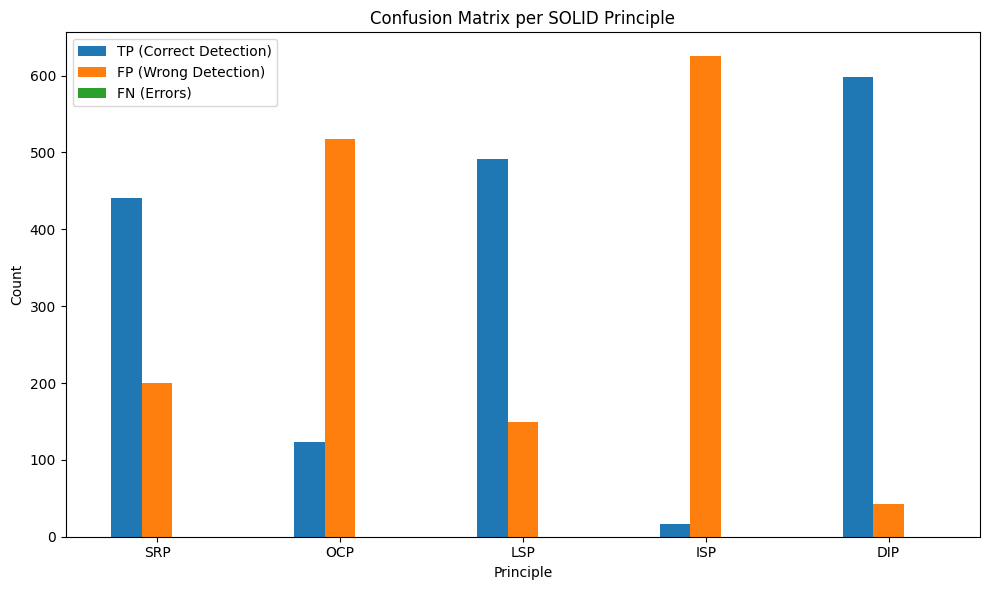

In [50]:
import matplotlib.pyplot as plt

plot_df = confusion_df.set_index("Principle")[["TP (Correct Detection)", "FP (Wrong Detection)", "FN (Errors)"]]

plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Confusion Matrix per SOLID Principle")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
def compute_metrics(subset):
    principle = subset["principle"].iloc[0]

    tp = ((subset["expected"] == subset["got"]) & (subset["outcome"] == "PASS")).sum()
    fp = ((subset["expected"] != subset["got"]) & (subset["outcome"] == "FAIL")).sum()
    fn = (subset["outcome"] == "ERROR").sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

    return pd.Series({
        "Principle": principle,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4),
        "Support": len(subset)
    })

metrics_df = (
    results_df
    .groupby("principle", group_keys=False)
    .apply(compute_metrics)
    .reset_index(drop=True)
)

display(metrics_df)




C:\Users\DELL\AppData\Local\Temp\ipykernel_3584\47698545.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_metrics)


,Principle,TP,FP,FN,Precision,Recall,F1-score,Support
0,DIP,598,43,0,0.9329,1.0,0.9653,641
1,ISP,16,625,0,0.0250,1.0,0.0487,641
2,LSP,492,149,0,0.7676,1.0,0.8685,641
3,OCP,123,518,0,0.1919,1.0,0.3220,641
4,SRP,441,200,0,0.6880,1.0,0.8152,641
